**Housing Price Prediction**

In [26]:
#Before starting anything first we need to import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

In [27]:
#Load the dataset from the library
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


**Seems interesting our lovely friend (PRICE) is not the data frame. I think we to need to satisfy him for working with us.**

In [28]:
df['price'] = data.target

In [29]:
#Look at the total number of friends that participate
Features = df.columns
print("Total number of features: ", len(Features))
print("=" * 40)
for i in Features:
     print(i)

Total number of features:  9
MedInc
HouseAge
AveRooms
AveBedrms
Population
AveOccup
Latitude
Longitude
price


In [30]:
#Now let's check the number of rows and columns
print("Number of rows: ", df.shape[0])
print("Number of columns: ", df.shape[1])
print("=" * 40)

#Now let's check the data types
print(df.dtypes)
print("=" * 40)

Number of rows:  20640
Number of columns:  9
MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
price         float64
dtype: object


**Great our all friends are numerical like they didn't like categorical data.**

In [31]:
#Now let see if there is any missing friends
print("Number of missing values: ", df.isnull().sum().sum())
print("=" * 40)
print(df.isnull().sum())

Number of missing values:  0
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
price         0
dtype: int64


**That's very appreciable, that our all friends are ready to participate.**

In [32]:
#Now let's check some random friends
df.sample(15)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
1263,3.6411,19.0,5.892174,1.041739,1707.0,2.968696,37.98,-121.68,1.628
20328,5.3806,17.0,7.697061,1.197438,3409.0,2.568953,34.24,-119.09,4.521
4840,1.0219,29.0,2.921682,1.140973,3323.0,2.739489,34.03,-118.29,2.583
16566,5.7500,2.0,10.223744,1.465753,766.0,3.497717,37.72,-121.45,2.402
186,2.9357,52.0,4.327670,0.958738,1659.0,4.026699,37.79,-122.23,1.079
16720,2.5437,6.0,4.506135,1.078221,2877.0,2.206288,35.46,-120.64,1.464
6176,4.1250,36.0,5.587500,0.990625,1139.0,3.559375,34.08,-117.93,1.858
16681,4.4033,15.0,6.885207,1.093491,2324.0,2.750296,35.13,-120.56,2.676
10770,3.6042,13.0,4.461957,1.149457,841.0,2.285326,33.66,-117.90,2.260
16959,2.9405,39.0,4.348531,1.111449,1758.0,1.781155,37.54,-122.30,3.405


In [33]:
#Check the statistical summary of the data
df.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


**Our main friend is price so we need to play with it.**

In [34]:
print("Statistical summary of price")
df['price'].describe().round(2)

Statistical summary of price


count    20640.00
mean         2.07
std          1.15
min          0.15
25%          1.20
50%          1.80
75%          2.65
max          5.00
Name: price, dtype: float64

In [35]:
#Now let's check in a different way
print("House Price Statistics ($100,000s mein):")
print(f"  Minimum : ${df['price'].min()*100:,.0f}k")
print(f"  Maximum : ${df['price'].max()*100:,.0f}k")
print(f"  Mean    : ${df['price'].mean()*100:,.0f}k")
print(f"  Median  : ${df['price'].median()*100:,.0f}k")
print(f"  Std Dev : ${df['price'].std()*100:,.0f}k")
print("=" * 40)
print(f"\nNote: $500k ceiling hai — bahut se expensive houses capped hain")

House Price Statistics ($100,000s mein):
  Minimum : $15k
  Maximum : $500k
  Mean    : $207k
  Median  : $180k
  Std Dev : $115k

Note: $500k ceiling hai — bahut se expensive houses capped hain


In [36]:
#Now check the skewness and kurtosis of price column
print("Skewness: ", df['price'].skew().round(2))
print("Kurtosis: ", df['price'].kurtosis().round(2))
print("=" * 40)

Skewness:  0.98
Kurtosis:  0.33


**Skewness:  0.9777632739098335, This means our data is skewed to the right**

**By using dist plot we can check the distribution of the price column.**

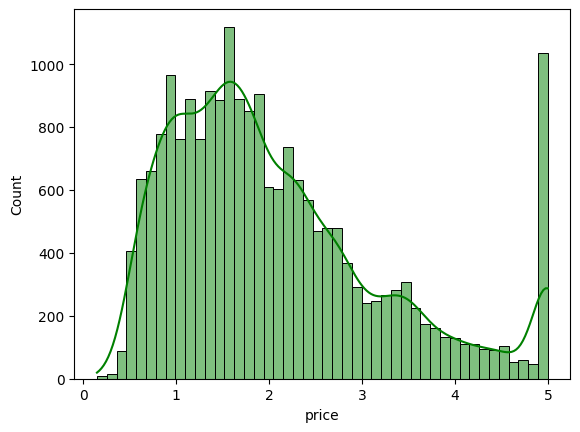

In [37]:
#Now check the distribution of price using dist plot
sns.histplot(df["price"], kde=True, color="green")
plots.show()

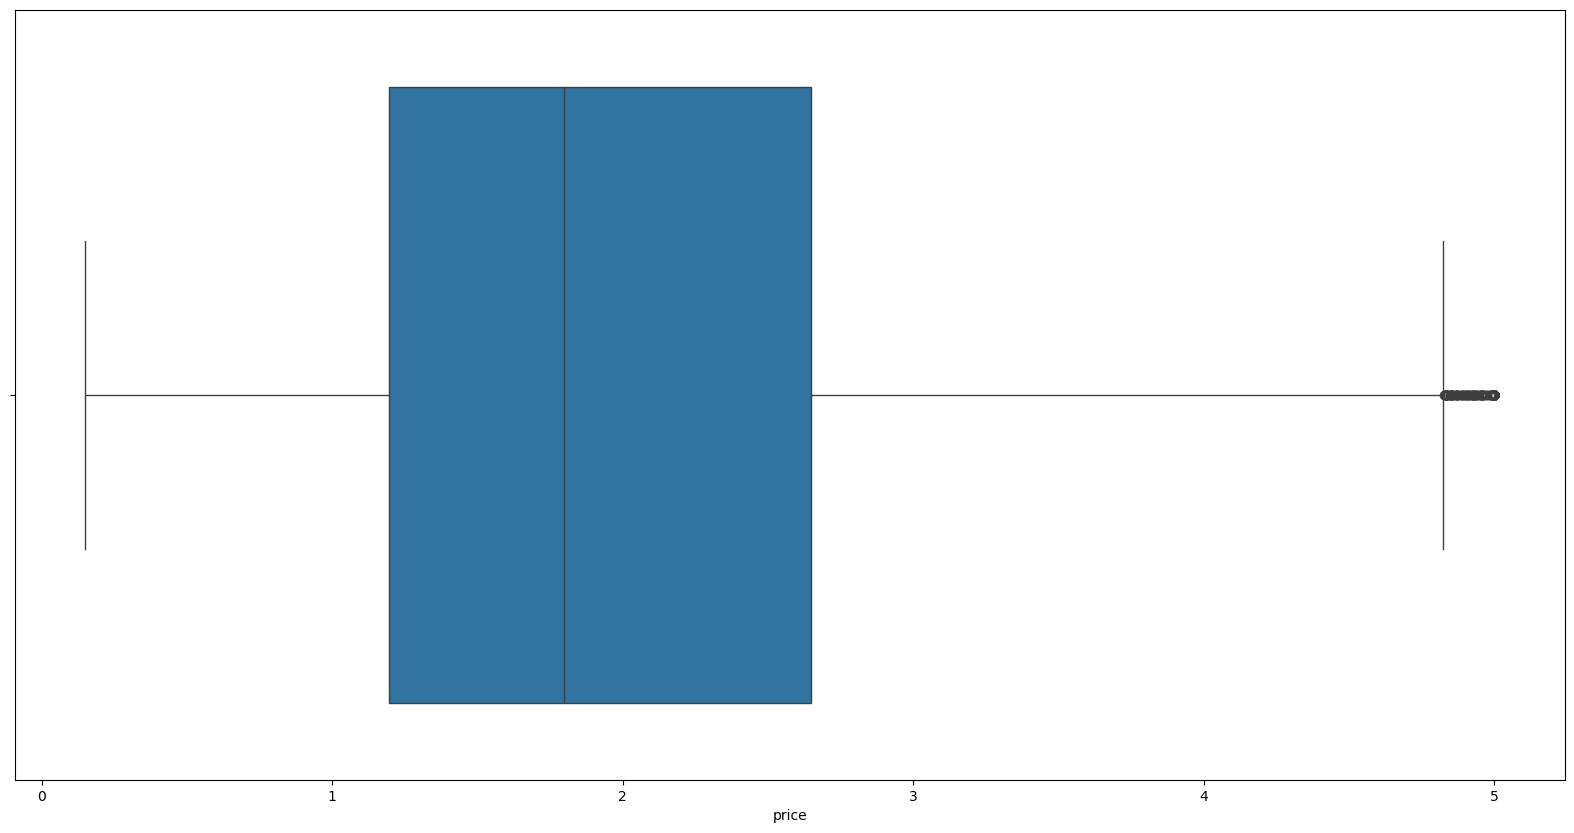

In [40]:
#now let's check the outliers using Box plot
fig = plt.figure(figsize=(20, 10))
sns.boxplot(data=df['price'], orient="h")
plt.show()

It seems that there are some outliers in our data

**The plot shows that in right side our some friends are very expensive.**

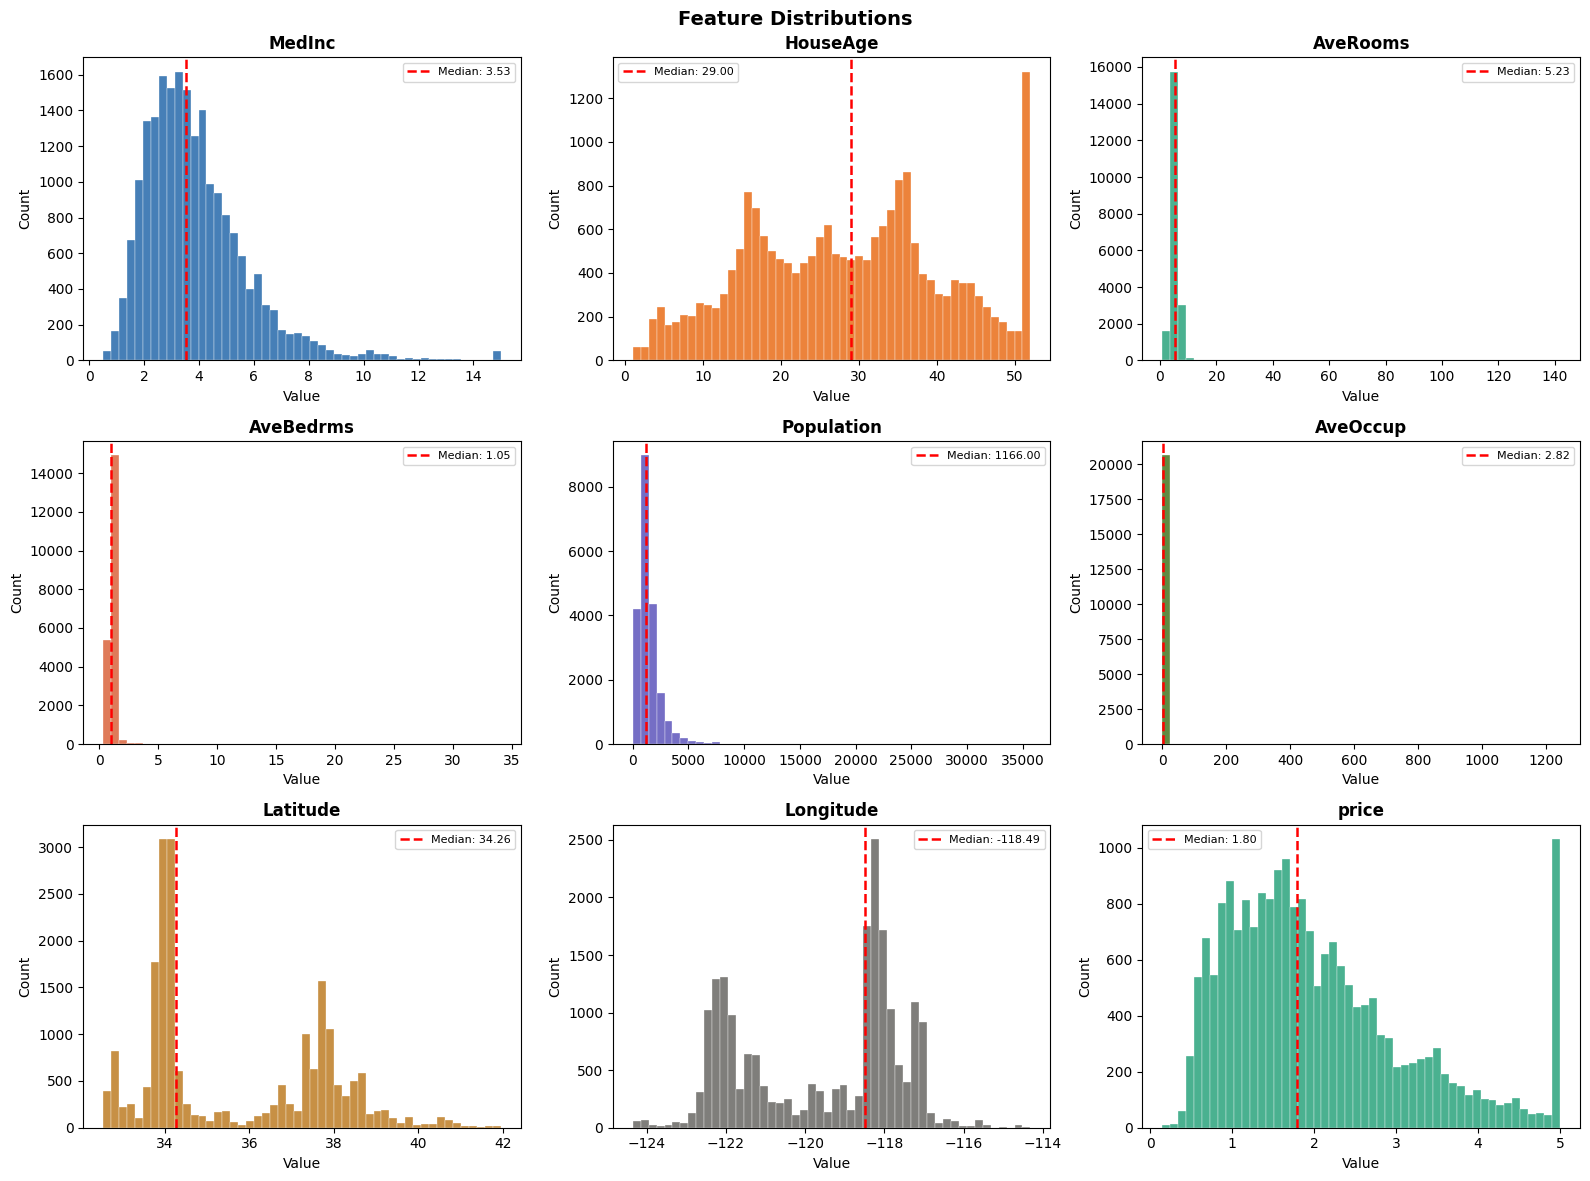

In [39]:
# %% ── CELL 7: Feature Distributions ───────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
 
colors = ['#185FA5','#E8640A','#1D9E75','#D85A30',
          '#534AB7','#3B6D11','#BA7517','#5F5E5A','#1D9E75']
 
for i, (col, clr) in enumerate(zip(df.columns, colors)):
    axes[i].hist(df[col], bins=50, color=clr,
                 alpha=0.8, edgecolor='white', linewidth=0.3)
    axes[i].axvline(df[col].median(), color='red',
                    linestyle='--', linewidth=1.8,
                    label=f'Median: {df[col].median():.2f}')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)
 
plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**- MedInc: right-skewed (Most people are low income)**

**- Population: right-skewed (outliers)**

**- PRICE: $500k pe cap dikh raha hai (flat right end)**

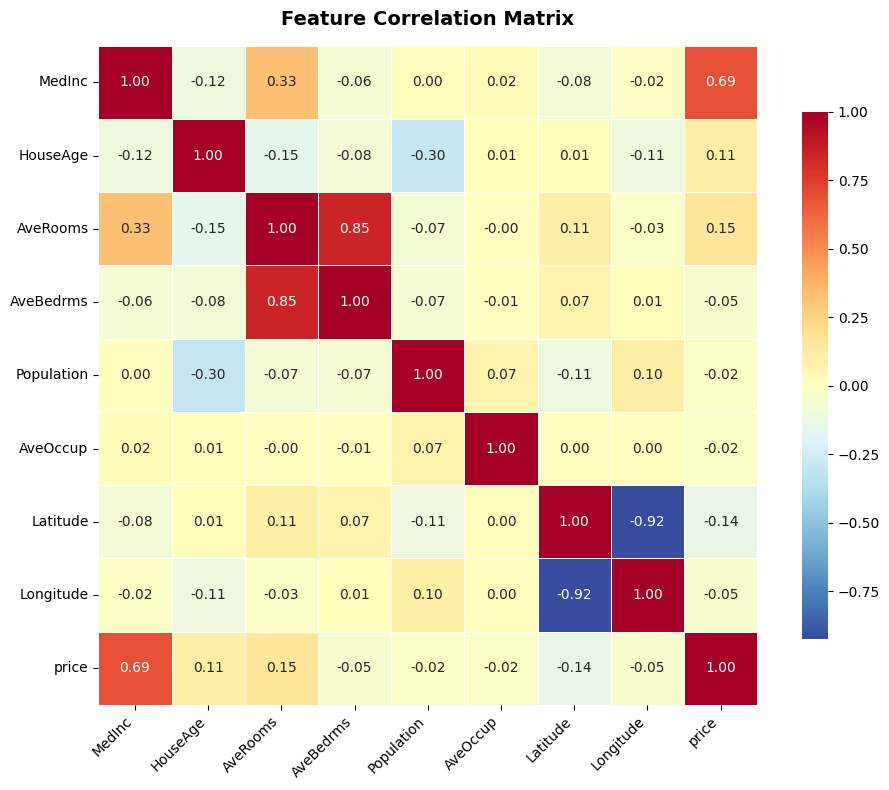

In [53]:
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(
    corr,
    annot=True,          # numbers dikhao
    fmt='.2f',           # 2 decimal places
    cmap='RdYlBu_r',     # red=negative, blue=positive
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**- MedInc aur PRICE ka strong positive correlation (blue)**

**- Latitude/Longitude ka apas mein correlation (location)**

In [56]:
#Now let's check the correlation of different features with price
print("Correlation of other features with price")
print("=" * 40)
df.corrwith(df['price']).sort_values(ascending=False)

Correlation of other features with price


price         1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
dtype: float64

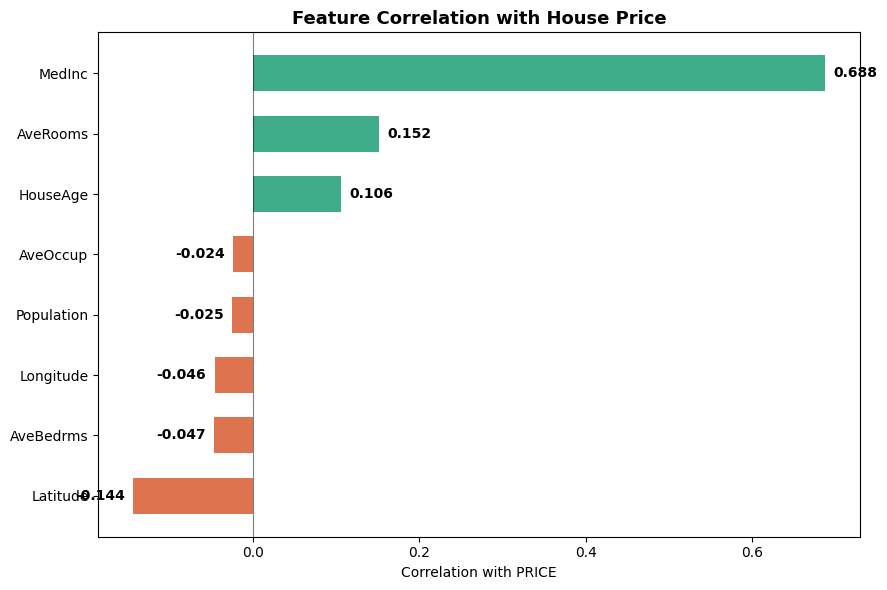

In [61]:
#Now let's check the correlation of different features with price by using plot
price_corr = df.corr()['price'].drop('price').sort_values()
 
plt.figure(figsize=(9, 6))
colors = ['#D85A30' if v < 0 else '#1D9E75' for v in price_corr.values]
bars = plt.barh(price_corr.index, price_corr.values,
                color=colors, alpha=0.85, height=0.6)
plt.axvline(0, color='black', linewidth=0.8, alpha=0.5)
 
for bar, val in zip(bars, price_corr.values):
    plt.text(val + (0.01 if val >= 0 else -0.01),
             bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center',
             ha='left' if val >= 0 else 'right',
             fontsize=10, fontweight='bold')
 
plt.xlabel('Correlation with PRICE')
plt.title('Feature Correlation with House Price', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**MedInc (income) → STRONGEST positive (r ≈ 0.69)**

**AveOccup→ STRONGEST negative (r ≈ -0.19)**

**HouseAge, Lat/Long → weaker correlations**

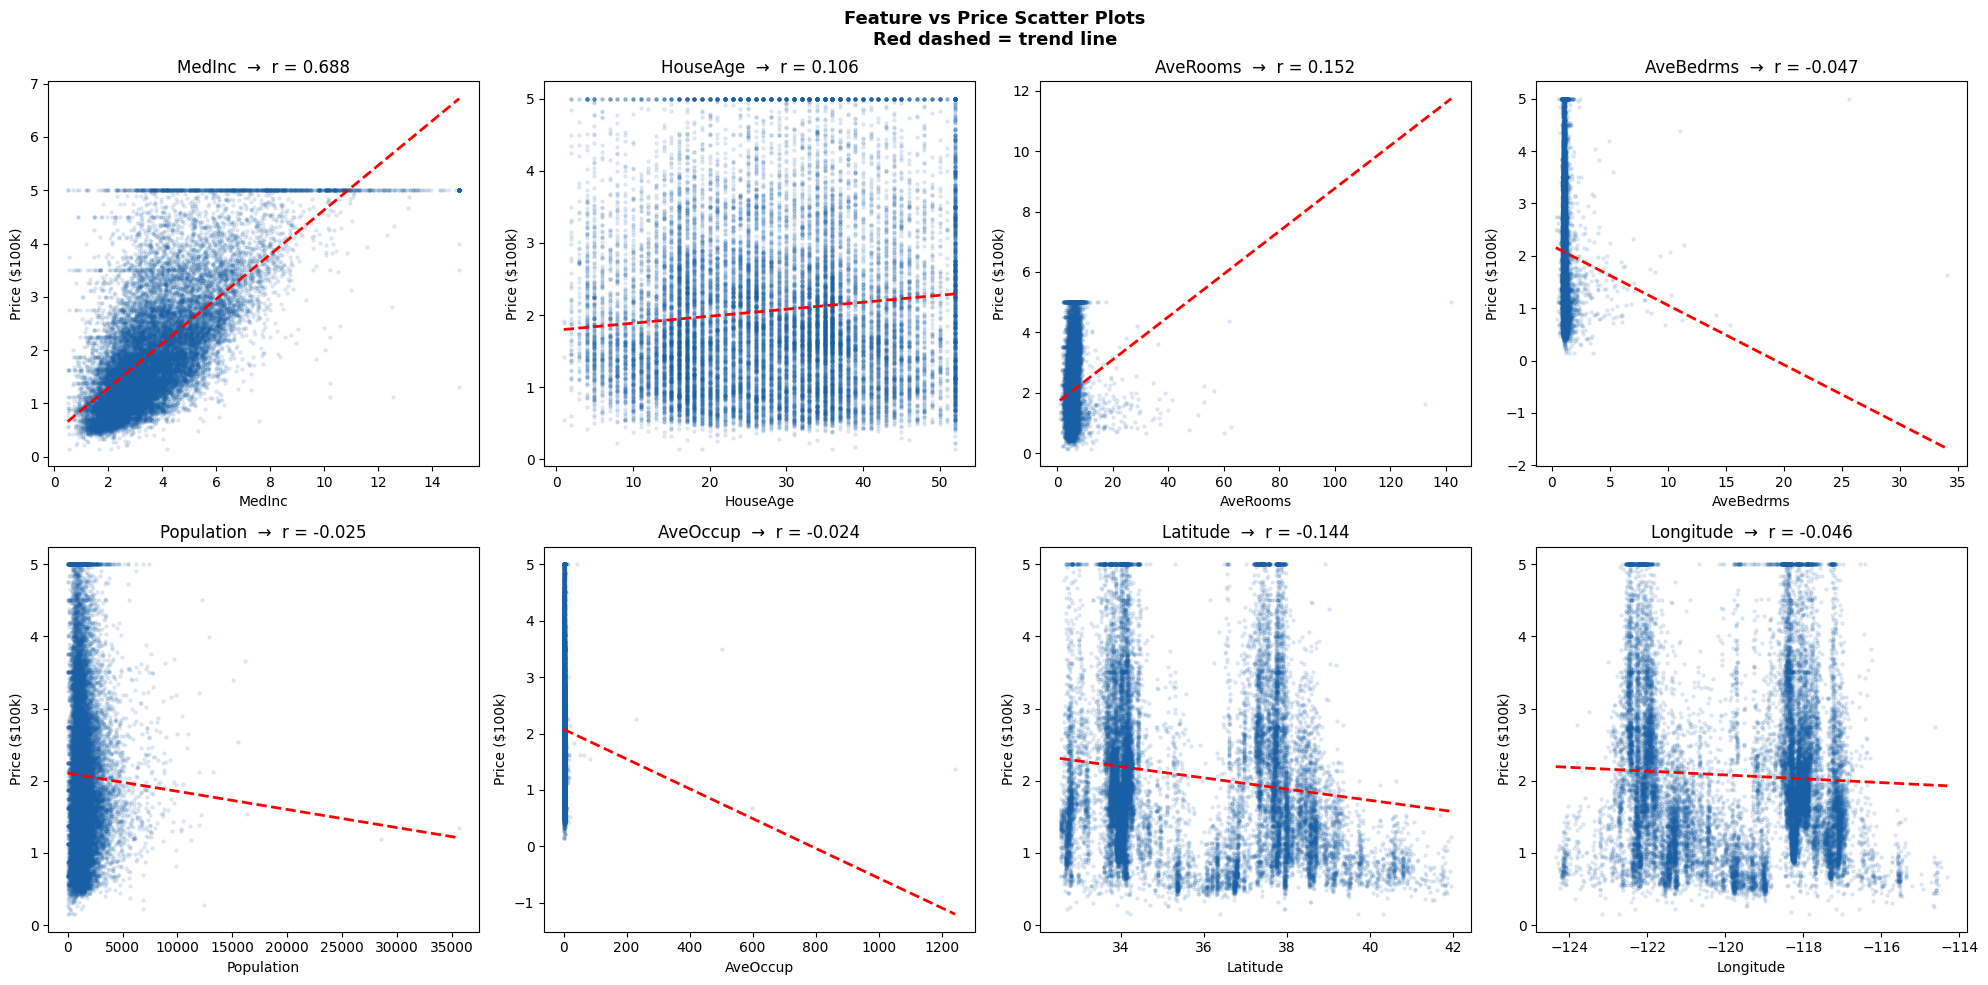

In [67]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
 
features = ['MedInc','HouseAge','AveRooms','AveBedrms',
            'Population','AveOccup','Latitude','Longitude']
 
for i, feat in enumerate(features):
    axes[i].scatter(df[feat], df['price'],
                    alpha=0.1, s=5, color='#185FA5')
 
    # Trend line
    z = np.polyfit(df[feat], df['price'], 1)
    xline = np.linspace(df[feat].min(), df[feat].max(), 100)
    axes[i].plot(xline, np.poly1d(z)(xline),
                 color='red', linewidth=2, linestyle='--')
 
    r = df[feat].corr(df['price'])
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Price ($100k)')
    axes[i].set_title(f'{feat}  →  r = {r:.3f}')
 
plt.suptitle('Feature vs Price Scatter Plots\nRed dashed = trend line',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**MedInc: clear upward trend ← most important feature**

**Population: no clear pattern ← weak feature**

**Latitude/Longitude: Bay Area aur LA expensive dikh rahe hain**

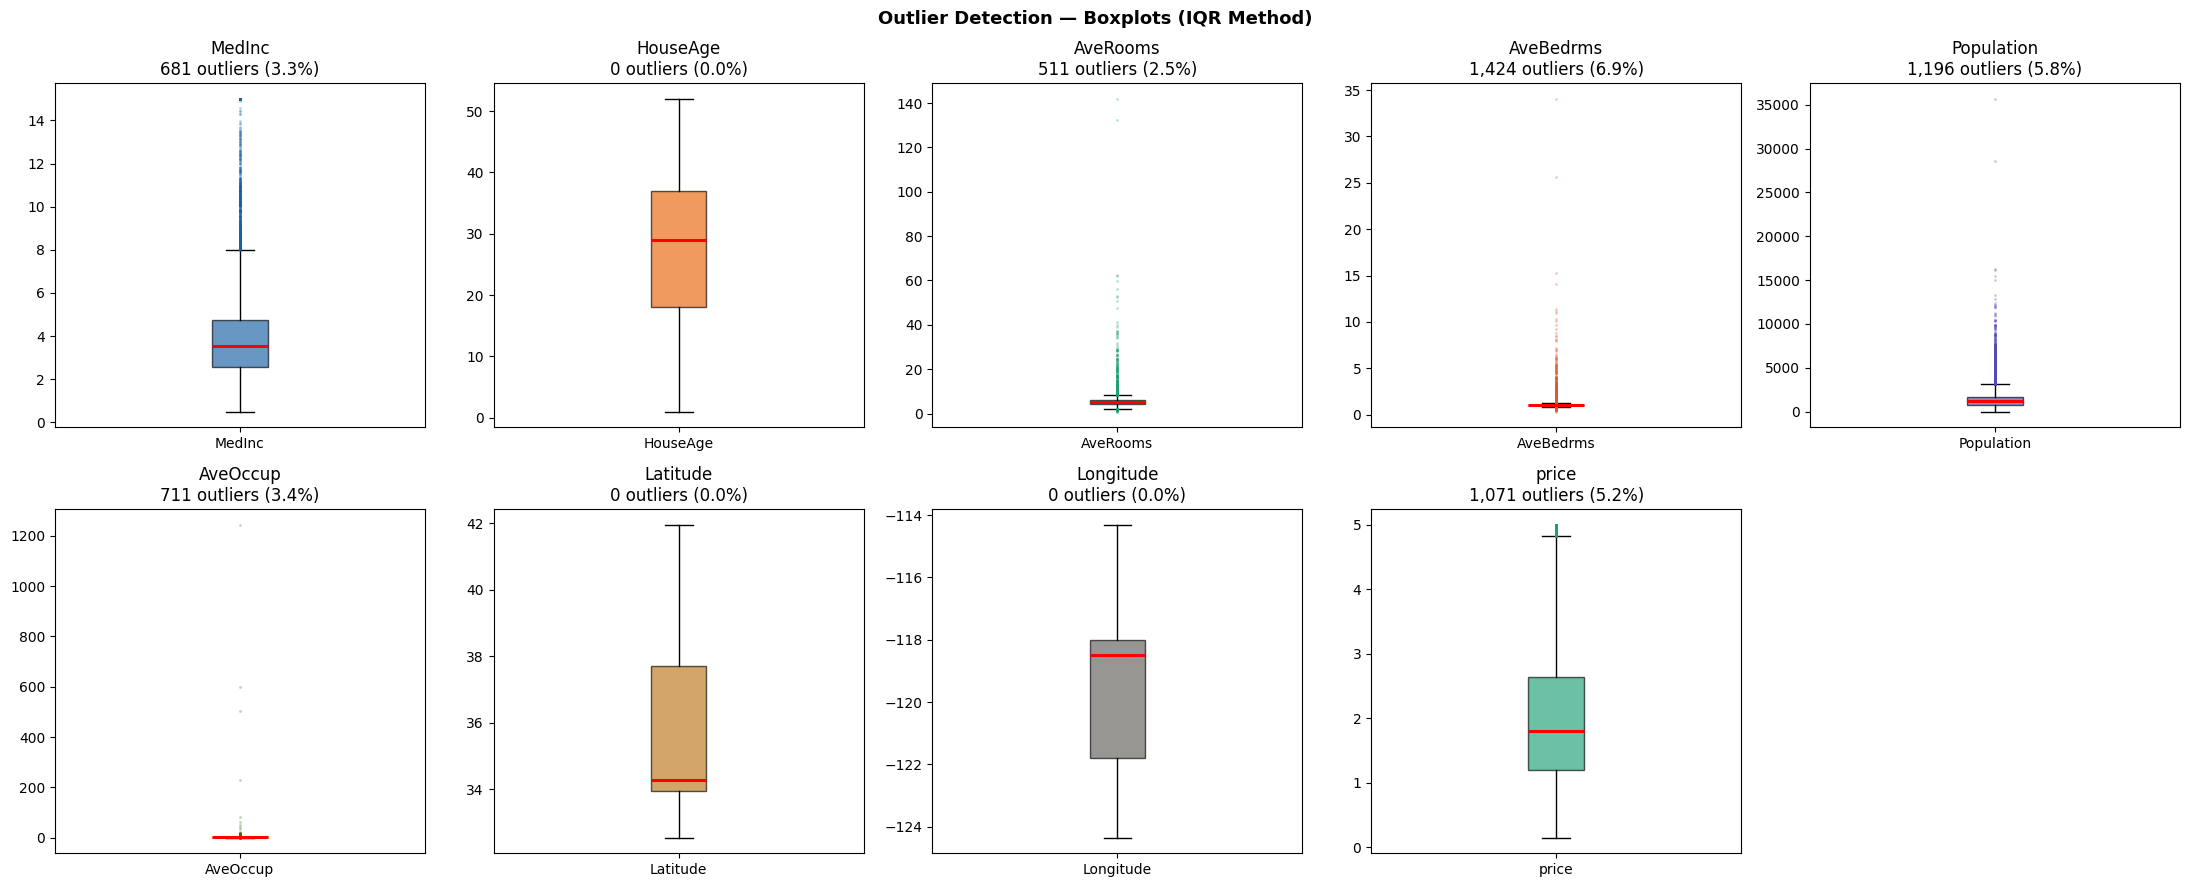

In [68]:
# %% ── CELL 11: Outlier Detection (Boxplots) ─────────────
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()
colors2 = ['#185FA5','#E8640A','#1D9E75','#D85A30','#534AB7',
           '#3B6D11','#BA7517','#5F5E5A','#1D9E75']
 
for i, (col, clr) in enumerate(zip(df.columns, colors2)):
    bp = axes[i].boxplot(
        df[col], patch_artist=True,
        medianprops=dict(color='red', linewidth=2.2),
        flierprops=dict(marker='o', markersize=2,
                        markerfacecolor=clr, alpha=0.3,
                        markeredgewidth=0)
    )
    bp['boxes'][0].set_facecolor(clr)
    bp['boxes'][0].set_alpha(0.65)
 
    # Outlier count calculate karo
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)).sum()
    pct = n_out/len(df)*100
 
    axes[i].set_title(f'{col}\n{n_out:,} outliers ({pct:.1f}%)')
    axes[i].set_xticklabels([col])
 
axes[-1].set_visible(False)
plt.suptitle('Outlier Detection — Boxplots (IQR Method)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()